### EDA

In [1]:
#### Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#### Data path
data_path = os.path.join(
    'Data',
    'clean_splac.csv'
)

#### Reading data
##### Reading data
df = pd.read_csv(
    data_path,
    parse_dates=['Date'],
    index_col='Date'
)

In [2]:
#### Overview summary
df_stats = df.describe().round(3)
df_stats.loc['current'] = df.iloc[-1].round(3)
df_stats.loc[['current','mean','std']].T.sort_values(by='current', ascending=False)

,current,mean,std
ISA.CL,30000.000,9467.484,5888.133
FALABELLA.SN,5875.000,3251.896,1261.634
CENCOSUD.SN,2180.000,1272.286,539.364
BAP,341.500,95.516,58.260
PAC,238.110,69.861,62.170
AC.MX,222.325,77.584,51.358
GMEXICOB.MX,213.608,42.802,37.581
FEMSAUBD.MX,206.338,100.918,50.206
SCCO,194.880,35.532,33.387
GFNORTEO.MX,185.150,60.613,40.637


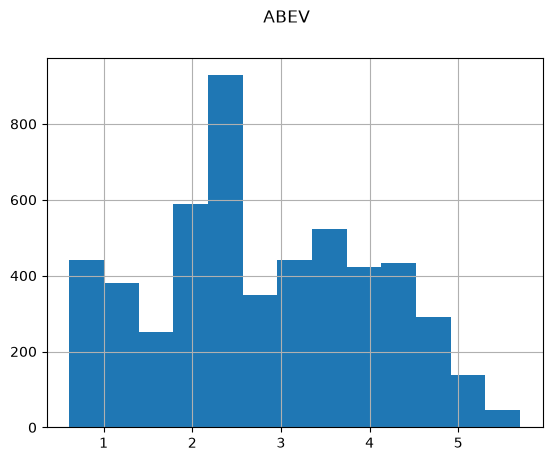

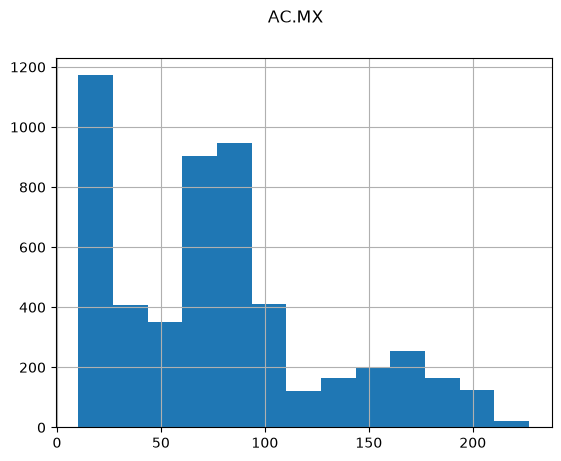

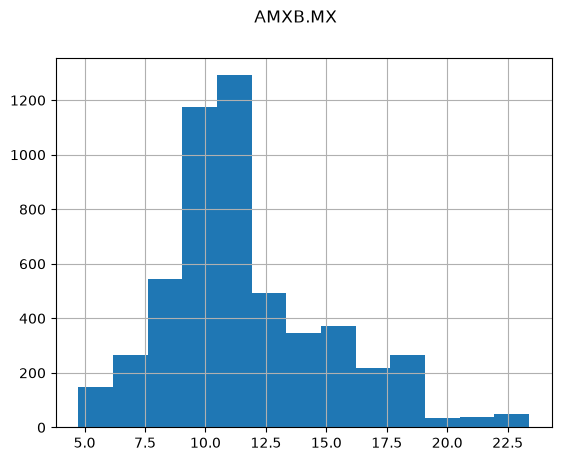

In [3]:
#### Histograms
num_bins = int(1 + (np.log(df.shape[0])/np.log(2)))
    #Sturges law
for i, col in enumerate(df.columns):
    df[col].hist(bins=num_bins)
    plt.suptitle(col)
    plt.show()
    if i == 2: break


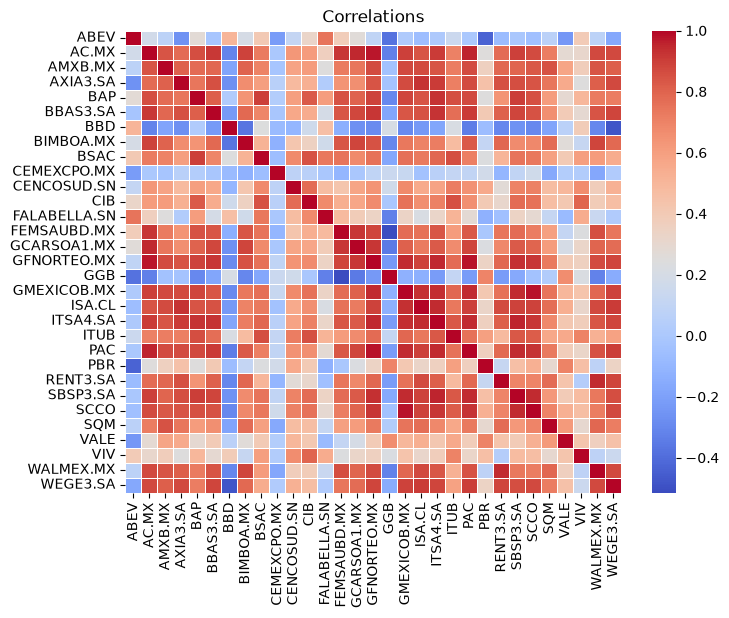

In [4]:
#### Correlation
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlations')
plt.show()

CEMEXCPO.MX     30.0
ABEV            22.0
BBD             21.0
GGB             20.0
FALABELLA.SN    14.0
PBR             11.0
VIV             10.0
VALE             9.0
RENT3.SA         7.0
SQM              6.0
BIMBOA.MX        6.0
BBAS3.SA         6.0
AXIA3.SA         6.0
GCARSOA1.MX      5.0
BAP              5.0
WEGE3.SA         5.0
SCCO             5.0
ISA.CL           5.0
FEMSAUBD.MX      5.0
CENCOSUD.SN      5.0
AMXB.MX          5.0
WALMEX.MX        5.0
AC.MX            4.0
GFNORTEO.MX      4.0
BSAC             4.0
PAC              4.0
GMEXICOB.MX      4.0
ITSA4.SA         4.0
ITUB             4.0
SBSP3.SA         4.0
CIB              3.0
dtype: float64

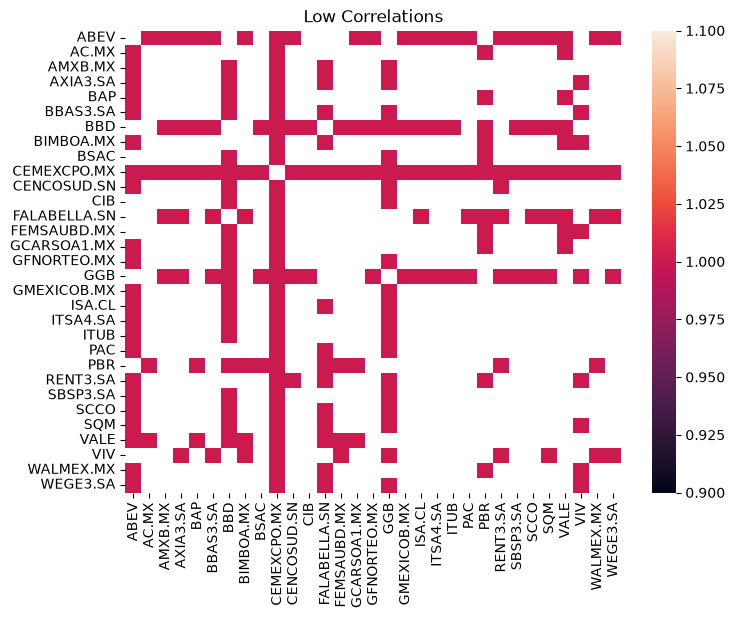

In [5]:
#### Identifying low correlations (|corr| < 0.3)
THRESH = 0.3
df_corr = df.corr()
df_corr[~((df_corr < THRESH) & (df_corr > -THRESH))] = np.nan
df_corr[(df_corr < THRESH) & (df_corr > -THRESH)] = 1
display(df_corr.sum().sort_values(ascending=False))
plt.figure(figsize=(8,6))
sns.heatmap(df_corr)
plt.title('Low Correlations')
plt.show()

In [6]:
#### USing KMeans
### Transforming Correlation to distance
df_corr_dist = 1 - df.corr()